# Empirical Win Probability from Historical IPL Data

Build a data-driven win probability model from 1184 IPL matches (cricsheet).

For each ball in a chase, record the state `(runs_needed, balls_remaining, wickets_fallen)` and whether the chasing team ultimately won. Bin these states and compute observed win rate — no formula, just history.

In [1]:
import json
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

IPL_DIR = r'C:\Users\hp\AppData\Local\Temp\cricket_data\ipl_all'

## Step 1: Parse all IPL matches into chase states

In [2]:
def parse_chase_states(match_path):
    """Return a list of per-ball chase states + outcome for one match."""
    with open(match_path) as f:
        d = json.load(f)

    # Need exactly 2 innings (completed chase)
    if len(d['innings']) < 2:
        return []

    outcome = d['info'].get('outcome', {})
    # Skip ties, no results, DLS-affected where winner is ambiguous
    if 'winner' not in outcome:
        return []

    inn1, inn2 = d['innings'][0], d['innings'][1]
    chasing_team = inn2['team']
    chaser_won = int(outcome['winner'] == chasing_team)

    # Inn1 final score
    inn1_score = sum(ball['runs']['total']
                     for ov in inn1['overs'] for ball in ov['deliveries'])
    target = inn1_score + 1

    # Total legal balls in inn1 (handles rain-reduced)
    total_balls = sum(
        1 for ov in inn1['overs'] for ball in ov['deliveries']
        if 'wides' not in ball.get('extras', {}) and 'noballs' not in ball.get('extras', {})
    )

    rows = []
    score = 0
    wickets = 0
    legal_ball = 0

    for ov in inn2['overs']:
        for ball in ov['deliveries']:
            extras_type = list(ball.get('extras', {}).keys())
            is_legal = 'wides' not in extras_type and 'noballs' not in extras_type
            score += ball['runs']['total']
            if 'wickets' in ball:
                wickets += len(ball['wickets'])
            if is_legal:
                legal_ball += 1
                runs_needed = target - score
                balls_remaining = total_balls - legal_ball

                rows.append({
                    'runs_needed': runs_needed,
                    'balls_remaining': balls_remaining,
                    'wickets_fallen': wickets,
                    'legal_ball': legal_ball,
                    'total_balls': total_balls,
                    'chaser_won': chaser_won,
                })

    return rows


all_rows = []
skipped = 0
for fname in os.listdir(IPL_DIR):
    if not fname.endswith('.json'):
        continue
    try:
        rows = parse_chase_states(os.path.join(IPL_DIR, fname))
        all_rows.extend(rows)
    except Exception:
        skipped += 1

df = pd.DataFrame(all_rows)
print(f'Total ball-states: {len(df):,}  |  Matches skipped: {skipped}')
print(f'Overall chaser win rate: {df["chaser_won"].mean():.3f}')
df.head()

Total ball-states: 128,511  |  Matches skipped: 0
Overall chaser win rate: 0.521


,runs_needed,balls_remaining,wickets_fallen,legal_ball,total_balls,chaser_won
0,207,119,0,1,120,0
1,207,118,0,2,120,0
2,207,117,0,3,120,0
3,205,116,0,4,120,0
4,201,115,0,5,120,0


## Step 2: Bin states and compute empirical win probability

Bins: `runs_needed` in steps of 5, `balls_remaining` in steps of 6 (1 over), `wickets_fallen` as-is.
Minimum 10 samples per bin to be included.

In [3]:
df['rn_bin'] = (df['runs_needed'] // 5) * 5          # e.g. 23 → 20
df['br_bin'] = (df['balls_remaining'] // 6) * 6      # e.g. 14 → 12
df['wk_bin'] = df['wickets_fallen'].clip(0, 9)

emp = (
    df.groupby(['rn_bin', 'br_bin', 'wk_bin'])
    .agg(win_rate=('chaser_won', 'mean'), n=('chaser_won', 'count'))
    .reset_index()
)
emp = emp[emp['n'] >= 10]  # only trust bins with enough samples

print(f'Bins with >= 10 samples: {len(emp):,}')
emp.sort_values('n', ascending=False).head(10)

Bins with >= 10 samples: 2,112


,rn_bin,br_bin,wk_bin,win_rate,n
3031,160,114,0,0.558386,471
3096,165,114,0,0.497436,390
2964,155,114,0,0.682415,381
3205,175,114,0,0.513514,370
3150,170,114,0,0.508333,360
3254,180,114,0,0.456825,359
2961,155,108,0,0.597101,345
2897,150,108,0,0.730303,330
2901,150,114,0,0.715170,323
3147,170,108,0,0.461059,321


## Step 3: Lookup function — empirical win prob for any state

In [4]:
# Build a dict for O(1) lookup
emp_lookup = {
    (row.rn_bin, row.br_bin, row.wk_bin): row.win_rate
    for row in emp.itertuples()
}

def empirical_win_prob(runs_needed, balls_remaining, wickets_fallen):
    """Look up empirical win prob. Falls back to nearest bin if exact miss."""
    rn  = int((runs_needed // 5) * 5)
    br  = int((balls_remaining // 6) * 6)
    wk  = int(min(wickets_fallen, 9))
    key = (rn, br, wk)
    if key in emp_lookup:
        return emp_lookup[key]
    # Fallback: relax wickets bin, then relax runs bin
    for wk_off in [1, -1, 2, -2]:
        k2 = (rn, br, max(0, min(9, wk + wk_off)))
        if k2 in emp_lookup:
            return emp_lookup[k2]
    # Last resort: just use runs_needed / balls_remaining ratio
    if balls_remaining <= 0:
        return 0.0 if runs_needed > 0 else 1.0
    return float(np.clip(1 - (runs_needed / (balls_remaining * 1.45 + 1)), 0.02, 0.98))

# Quick sanity checks
print('Need 1 off 6, 0 wkts:', empirical_win_prob(1, 6, 0))    # should be near 1
print('Need 30 off 6, 0 wkts:', empirical_win_prob(30, 6, 0))   # near 0
print('Need 12 off 12, 5 wkts:', empirical_win_prob(12, 12, 5)) # roughly 50/50

Need 1 off 6, 0 wkts: 1.0
Need 30 off 6, 0 wkts: 0.02
Need 12 off 12, 5 wkts: 1.0


## Step 4: Apply to our 4 matches and compare vs formula model

In [5]:
import sys
sys.path.insert(0, '..')

# Re-use parse helpers from notebook 01 (copy inline to keep this notebook self-contained)
def parse_innings(match_data, innings_idx):
    rows = []
    inn = match_data['innings'][innings_idx]
    cumulative = 0
    wickets = 0
    legal_ball = 0
    for ov in inn['overs']:
        for ball in ov['deliveries']:
            extras_type = list(ball.get('extras', {}).keys())
            is_legal = 'wides' not in extras_type and 'noballs' not in extras_type
            cumulative += ball['runs']['total']
            if 'wickets' in ball:
                wickets += len(ball['wickets'])
            if is_legal:
                legal_ball += 1
            rows.append({
                'legal_ball': legal_ball,
                'score': cumulative,
                'wickets_fallen': wickets,
                'is_legal': is_legal,
                'is_wicket': 'wickets' in ball,
            })
    return pd.DataFrame(rows)

def add_win_probs(bat1_df, bat2_df):
    target = bat1_df['score'].iloc[-1] + 1
    total_balls = bat1_df[bat1_df['is_legal']]['legal_ball'].max()
    df = bat2_df[bat2_df['is_legal']].copy().reset_index(drop=True)

    df['target'] = target
    df['runs_needed'] = target - df['score']
    df['balls_remaining'] = total_balls - df['legal_ball']

    # Formula model (from notebook 01)
    avg_rate, sensitivity = 1.45, 15
    wih = 10 - df['wickets_fallen']
    expected = df['balls_remaining'] * avg_rate * (wih / 10) ** 0.5
    gap = expected - df['runs_needed']
    df['win_prob_formula'] = (1 / (1 + np.exp(-gap / sensitivity))).clip(0.02, 0.98)

    # Empirical model
    df['win_prob_empirical'] = df.apply(
        lambda r: empirical_win_prob(r['runs_needed'], r['balls_remaining'], r['wickets_fallen']),
        axis=1
    )

    return df, target, total_balls


from pathlib import Path

DATA = '../data/raw/'

FIG_DIR = Path('../data/figures/02_empirical_win_prob')
FIG_DIR.mkdir(parents=True, exist_ok=True)
matches = {
    'DC vs GT (HOT)':      ('dc_vs_gt_2026-04-08.json',),
    'IND vs PAK (HOT)':    ('ind_vs_pak_2024-06-09.json',),
    'RR vs MI (COLD)':     ('rr_vs_mi_2026-04-07.json',),
    'MI vs RR (COLD)':     ('mi_vs_rr_2025-05-01.json',),
}

results = {}
for label, (fname,) in matches.items():
    d = json.load(open(DATA + fname))
    inn = [parse_innings(d, i) for i in range(len(d['innings']))]
    chase, target, total_balls = add_win_probs(inn[0], inn[1])
    results[label] = chase
    print(f'{label}: target={target}, balls={total_balls}, final={int(chase["score"].iloc[-1])}/{int(chase["wickets_fallen"].iloc[-1])}')

DC vs GT (HOT): target=211, balls=120, final=209/8
IND vs PAK (HOT): target=120, balls=114, final=113/7
RR vs MI (COLD): target=151, balls=66, final=123/9
MI vs RR (COLD): target=218, balls=120, final=117/10


## Step 5: Plot — Formula vs Empirical win probability

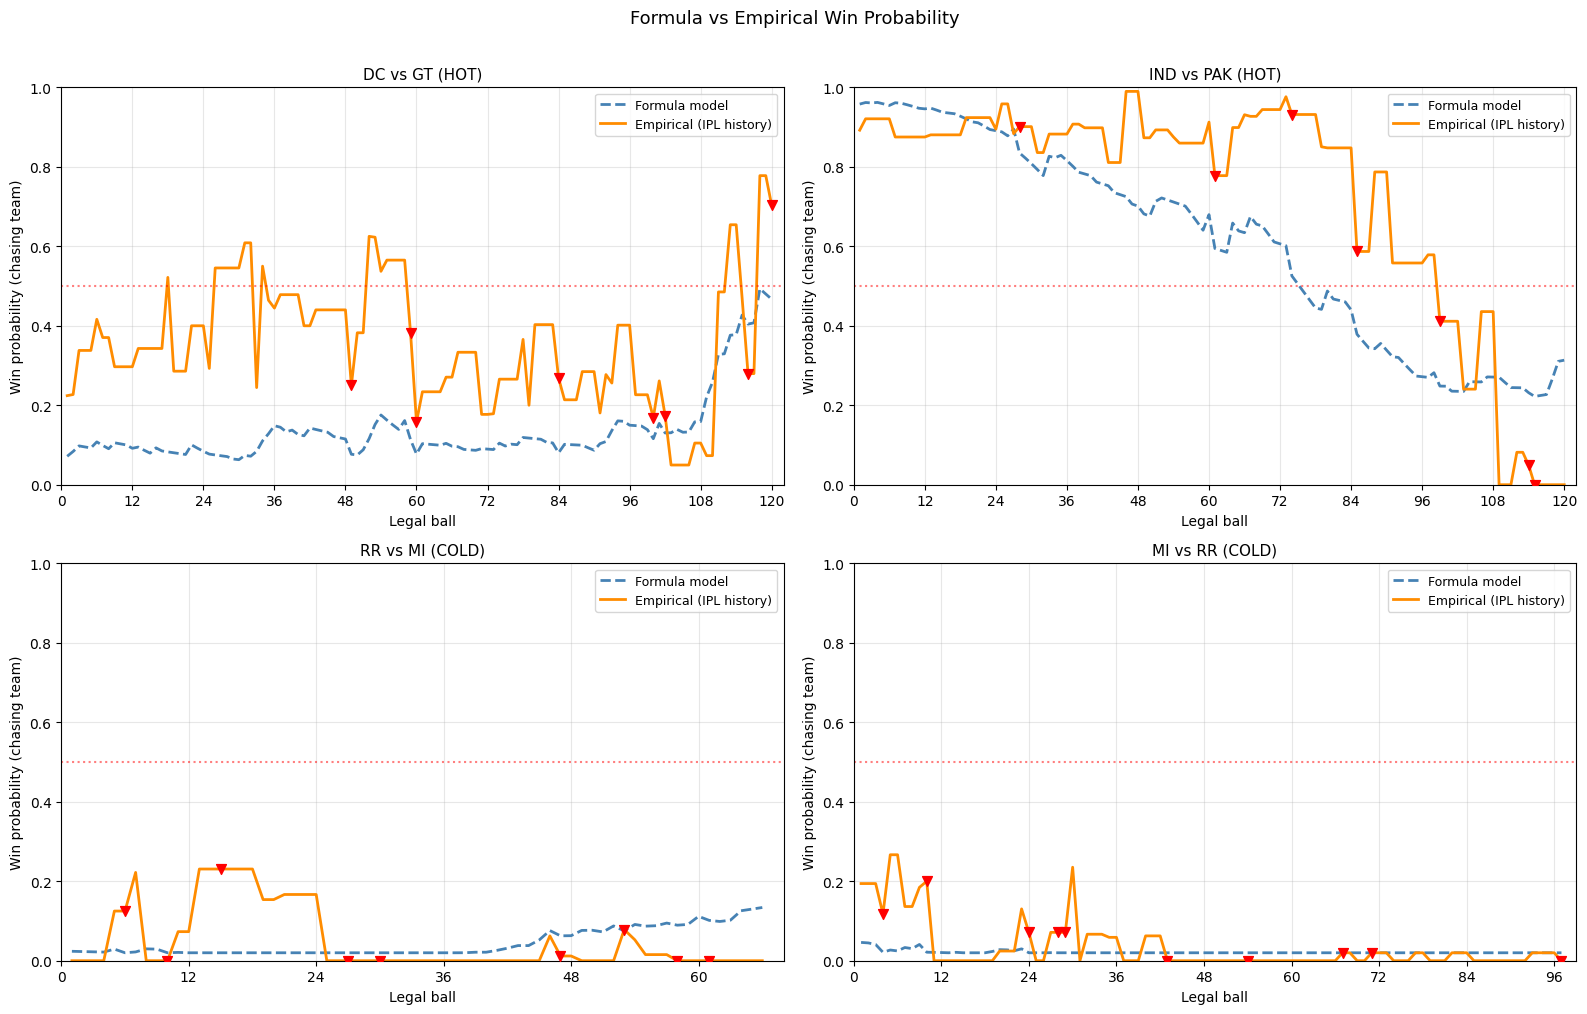

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, (label, chase) in zip(axes, results.items()):
    ax.plot(chase['legal_ball'], chase['win_prob_formula'],
            label='Formula model', color='steelblue', linewidth=2, linestyle='--')
    ax.plot(chase['legal_ball'], chase['win_prob_empirical'],
            label='Empirical (IPL history)', color='darkorange', linewidth=2)
    ax.axhline(0.5, color='red', linestyle=':', alpha=0.5)
    wicket_balls = chase[chase['is_wicket']]
    ax.scatter(wicket_balls['legal_ball'], wicket_balls['win_prob_empirical'],
               color='red', zorder=5, s=50, marker='v')
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('Legal ball')
    ax.set_ylabel('Win probability (chasing team)')
    ax.set_ylim(0, 1)
    ax.set_xlim(0, chase['legal_ball'].max() + 2)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(12))
    ax.legend(fontsize=9)

plt.suptitle('Formula vs Empirical Win Probability', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'win_prob_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 5b: Tune the formula — what avg_rate and sensitivity fit best?

Key constraint from domain knowledge: **200 is roughly a 50/50 target in IPL** at the start of a chase.

`win_prob = sigmoid((balls_remaining * avg_rate * wickets_factor - runs_needed) / sensitivity)`

For win_prob = 0.5 at ball 1 (120 balls, 10 wickets): `120 * avg_rate = 200` → `avg_rate = 1.667`

Sensitivity controls how steeply win_prob changes around the 50/50 point.
A higher sensitivity = softer curve = more matches feel uncertain.

In [7]:
# --- Parameters to fiddle with ---
AVG_RATE   = 1.667   # runs/ball at which win_prob=0.5 for full-over chase: 120*AVG_RATE = breakeven target
SENSITIVITY = 20     # higher = softer curve (more matches feel contested)
# ----------------------------------

def formula_win_prob(runs_needed, balls_remaining, wickets_fallen,
                     avg_rate=AVG_RATE, sensitivity=SENSITIVITY):
    wih = 10 - wickets_fallen
    expected = balls_remaining * avg_rate * (wih / 10) ** 0.5
    gap = expected - runs_needed
    return float(np.clip(1 / (1 + np.exp(-gap / sensitivity)), 0.02, 0.98))

# Table: starting win_prob (ball 1, 10 wickets) for a range of targets
print("Starting win_prob at ball 1 (10 wkts in hand):")
print(f"{'Target':>8} {'avg=1.45 s=15':>15} {'avg=1.667 s=20 (new)':>22} {'Empirical (0 wkts)':>20}")
print("-" * 70)
for target in [120, 140, 160, 180, 200, 210, 220, 240]:
    old = formula_win_prob(target, 119, 0, avg_rate=1.45, sensitivity=15)
    new = formula_win_prob(target, 119, 0, avg_rate=AVG_RATE, sensitivity=SENSITIVITY)
    emp = empirical_win_prob(target, 119, 0)
    print(f"{target:>8}      {old:>10.3f}           {new:>10.3f}           {emp:>10.3f}")

Starting win_prob at ball 1 (10 wkts in hand):
  Target   avg=1.45 s=15   avg=1.667 s=20 (new)   Empirical (0 wkts)
----------------------------------------------------------------------
     120           0.971                0.980                0.875
     140           0.898                0.949                0.758
     160           0.698                0.872                0.558
     180           0.378                0.715                0.457
     200           0.138                0.480                0.338
     210           0.076                0.359                0.224
     220           0.041                0.253                0.171
     240           0.020                0.111                0.118


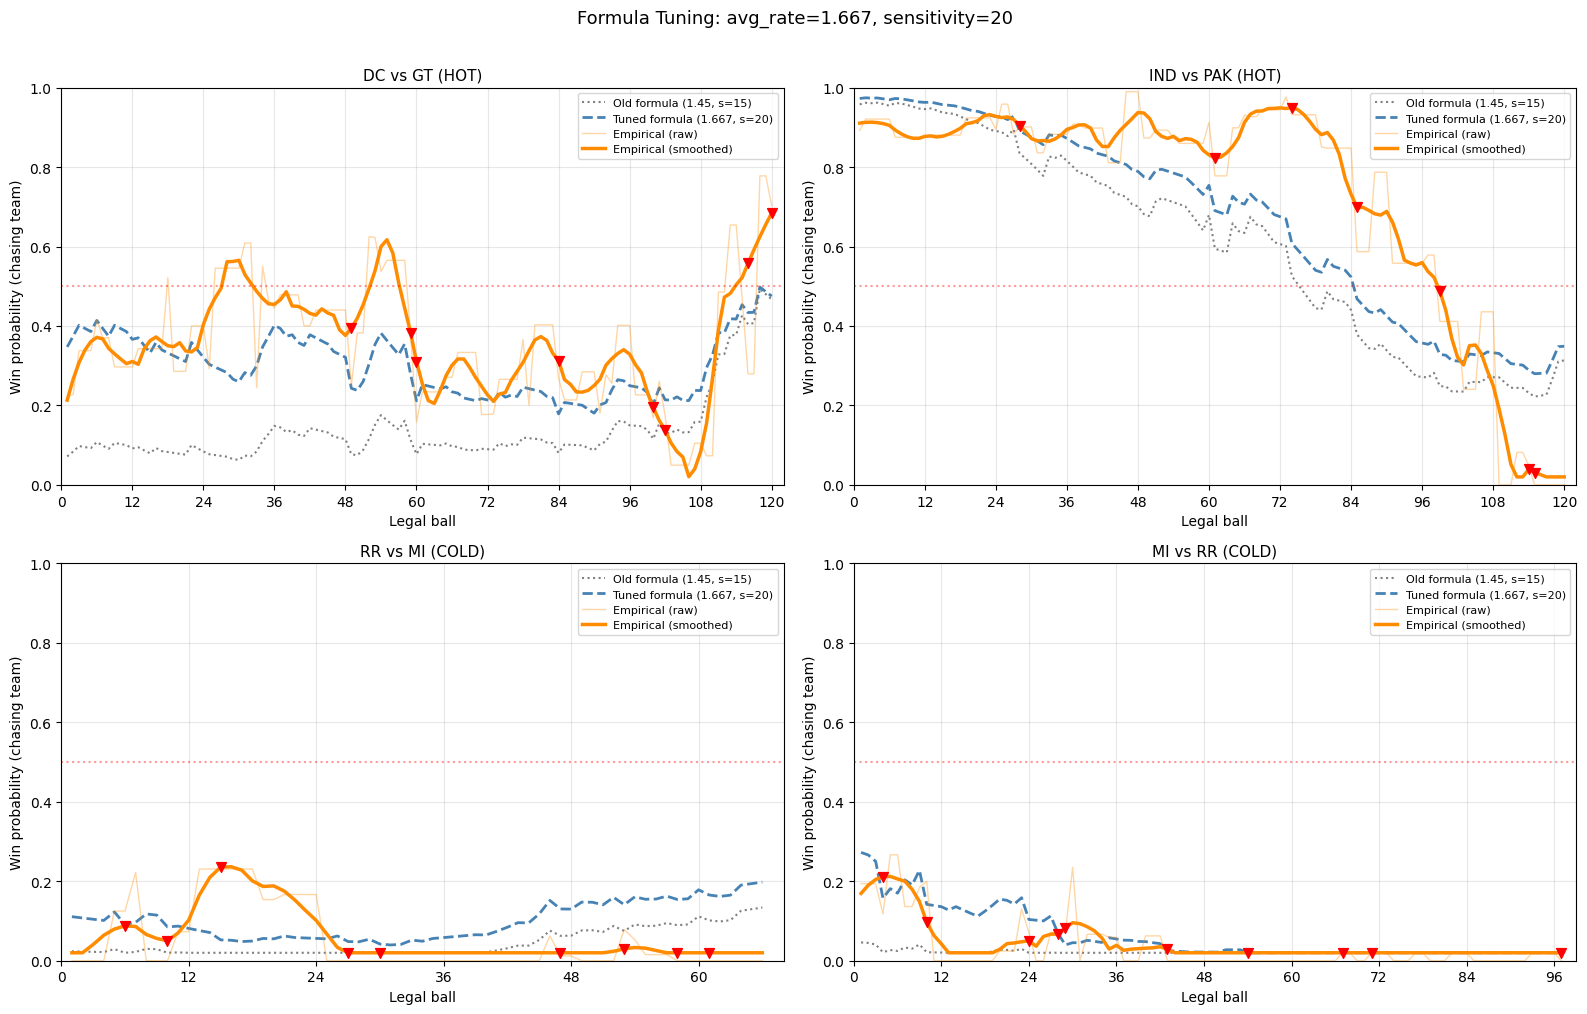


Match                      MAE (old)  MAE (tuned)
--------------------------------------------------
DC vs GT (HOT)                 0.229        0.093
IND vs PAK (HOT)               0.180        0.137
RR vs MI (COLD)                0.062        0.088
MI vs RR (COLD)                0.023        0.025


In [8]:
from scipy.signal import savgol_filter

# Recompute results with tuned formula and plot all 3 lines
def add_win_probs_tuned(bat1_df, bat2_df):
    target = bat1_df['score'].iloc[-1] + 1
    total_balls = bat1_df[bat1_df['is_legal']]['legal_ball'].max()
    df = bat2_df[bat2_df['is_legal']].copy().reset_index(drop=True)

    df['target'] = target
    df['runs_needed'] = target - df['score']
    df['balls_remaining'] = total_balls - df['legal_ball']

    # Old formula
    wih = 10 - df['wickets_fallen']
    expected_old = df['balls_remaining'] * 1.45 * (wih / 10) ** 0.5
    df['win_prob_old'] = (1 / (1 + np.exp(-(expected_old - df['runs_needed']) / 15))).clip(0.02, 0.98)

    # Tuned formula
    expected_new = df['balls_remaining'] * AVG_RATE * (wih / 10) ** 0.5
    df['win_prob_tuned'] = (1 / (1 + np.exp(-(expected_new - df['runs_needed']) / SENSITIVITY))).clip(0.02, 0.98)

    # Empirical (raw)
    df['win_prob_empirical'] = df.apply(
        lambda r: empirical_win_prob(r['runs_needed'], r['balls_remaining'], r['wickets_fallen']),
        axis=1
    )

    # Smoothed empirical — Savitzky-Golay (preserves peaks better than rolling mean)
    n = len(df)
    window = min(11, n if n % 2 == 1 else n - 1)  # must be odd and <= n
    if window >= 3:
        df['win_prob_empirical_smooth'] = savgol_filter(
            df['win_prob_empirical'], window_length=window, polyorder=2
        ).clip(0.02, 0.98)
    else:
        df['win_prob_empirical_smooth'] = df['win_prob_empirical']

    return df, target, total_balls


results_tuned = {}
for label, (fname,) in matches.items():
    d = json.load(open(DATA + fname))
    inn = [parse_innings(d, i) for i in range(len(d['innings']))]
    chase, target, total_balls = add_win_probs_tuned(inn[0], inn[1])
    results_tuned[label] = chase

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, (label, chase) in zip(axes, results_tuned.items()):
    ax.plot(chase['legal_ball'], chase['win_prob_old'],
            label='Old formula (1.45, s=15)', color='gray', linewidth=1.5, linestyle=':')
    ax.plot(chase['legal_ball'], chase['win_prob_tuned'],
            label=f'Tuned formula ({AVG_RATE}, s={SENSITIVITY})', color='steelblue', linewidth=2, linestyle='--')
    ax.plot(chase['legal_ball'], chase['win_prob_empirical'],
            label='Empirical (raw)', color='darkorange', linewidth=1, alpha=0.35)
    ax.plot(chase['legal_ball'], chase['win_prob_empirical_smooth'],
            label='Empirical (smoothed)', color='darkorange', linewidth=2.5)
    ax.axhline(0.5, color='red', linestyle=':', alpha=0.4)
    wicket_balls = chase[chase['is_wicket']]
    ax.scatter(wicket_balls['legal_ball'], wicket_balls['win_prob_empirical_smooth'],
               color='red', zorder=5, s=50, marker='v')
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('Legal ball')
    ax.set_ylabel('Win probability (chasing team)')
    ax.set_ylim(0, 1)
    ax.set_xlim(0, chase['legal_ball'].max() + 2)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(12))
    ax.legend(fontsize=8)

plt.suptitle(f'Formula Tuning: avg_rate={AVG_RATE}, sensitivity={SENSITIVITY}', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'win_prob_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

# MAE against smoothed empirical
print(f"\n{'Match':<25} {'MAE (old)':>10} {'MAE (tuned)':>12}")
print('-' * 50)
for label, chase in results_tuned.items():
    mae_old   = (chase['win_prob_old']   - chase['win_prob_empirical_smooth']).abs().mean()
    mae_tuned = (chase['win_prob_tuned'] - chase['win_prob_empirical_smooth']).abs().mean()
    print(f"{label:<25} {mae_old:>10.3f} {mae_tuned:>12.3f}")

## Step 6: How well do the two models agree?

Compute MAE and correlation between formula and empirical win_prob across all 4 matches.

In [9]:
print(f"{'Match':<25} {'MAE':>8} {'Corr':>8} {'Emp_max':>10} {'Form_max':>10}")
print('-' * 65)
for label, chase in results.items():
    mae  = (chase['win_prob_formula'] - chase['win_prob_empirical']).abs().mean()
    corr = chase['win_prob_formula'].corr(chase['win_prob_empirical'])
    print(f"{label:<25} {mae:>8.3f} {corr:>8.3f} "
          f"{chase['win_prob_empirical'].max():>10.3f} "
          f"{chase['win_prob_formula'].max():>10.3f}")

Match                          MAE     Corr    Emp_max   Form_max
-----------------------------------------------------------------
DC vs GT (HOT)               0.237    0.359      0.778      0.493
IND vs PAK (HOT)             0.185    0.766      0.990      0.962
RR vs MI (COLD)              0.075   -0.347      0.231      0.134
MI vs RR (COLD)              0.037    0.654      0.267      0.046


## Step 7: Coverage — how many balls had a valid empirical lookup?

In [10]:
for label, chase in results.items():
    # Empirical fallback gives exactly formula-like values — flag those
    rn_bins  = ((chase['runs_needed'] // 5) * 5).astype(int)
    br_bins  = ((chase['balls_remaining'] // 6) * 6).astype(int)
    wk_bins  = chase['wickets_fallen'].clip(0, 9).astype(int)
    hits = sum(1 for rn, br, wk in zip(rn_bins, br_bins, wk_bins)
               if (rn, br, wk) in emp_lookup)
    pct = hits / len(chase) * 100
    print(f'{label}: {hits}/{len(chase)} balls had direct empirical lookup ({pct:.0f}%)')

DC vs GT (HOT): 120/120 balls had direct empirical lookup (100%)
IND vs PAK (HOT): 114/120 balls had direct empirical lookup (95%)
RR vs MI (COLD): 54/66 balls had direct empirical lookup (82%)
MI vs RR (COLD): 27/97 balls had direct empirical lookup (28%)
